In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

подготовка данных

In [28]:
dataset = pd.read_csv("pricerunner_aggregate.csv")
dataset.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [29]:
print(dataset.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']


In [30]:
dataset = dataset.drop(' Category Label', axis = 1)

In [31]:
dataset = dataset.drop('Product Title', axis = 1)

In [32]:
dataset = dataset.drop('Product ID', axis = 1)

In [33]:
dataset = dataset.drop(' Cluster Label', axis = 1)

In [34]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,2612
1,2,1,2612
2,3,1,2612
3,4,1,2612
4,5,1,2612
...,...,...,...
35306,59,47517,2623
35307,59,47518,2623
35308,59,47519,2623
35309,125,47524,2623


In [35]:
dataset[' Category ID'] = pd.factorize(dataset[' Category ID'])[0]

In [36]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0
...,...,...,...
35306,59,47517,9
35307,59,47518,9
35308,59,47519,9
35309,125,47524,9


In [37]:
vals = dataset[" Category ID"].unique()
vals

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

посмотрим, как данные коррелируют друг с другом

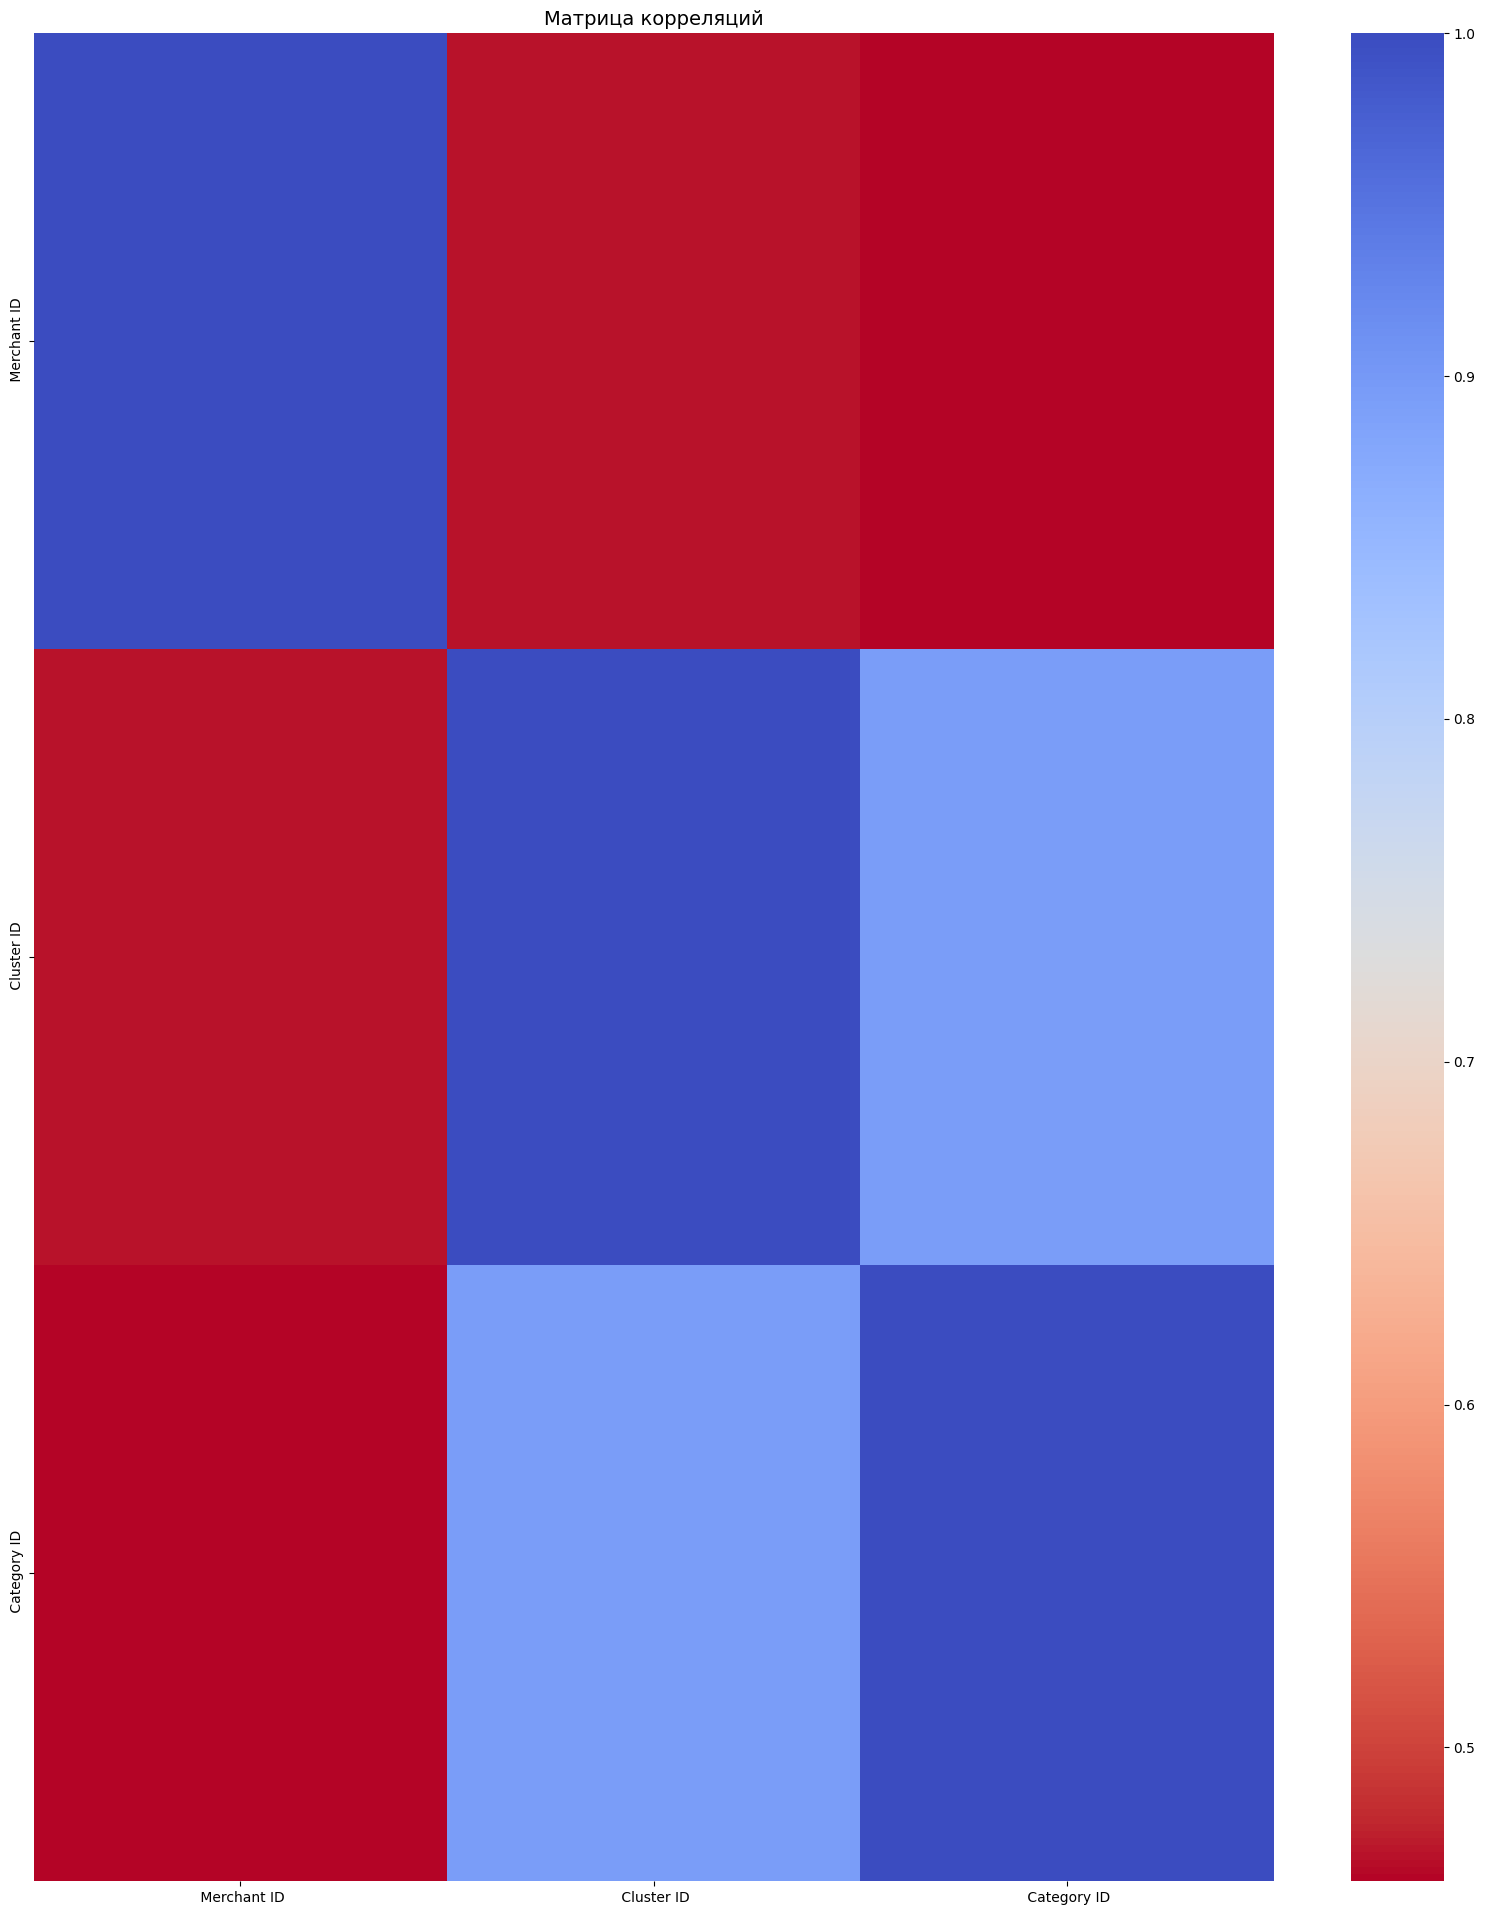

In [38]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = dataset.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций', fontsize=14)
plt.show()

что ж, кластер и категория хорошо друг с другом коррелируют, продавцы - намного хуже

создадим дисбаланс данных, я бы хотела найти именно предметы 8 категории, остальные меня не интересуют, можем обозначить их по-другому

In [39]:
# Сколько строк относится к каждой категории Category ID
print(dataset[' Category ID'].value_counts())

 Category ID
8    5501
0    4081
6    4044
2    3862
9    3584
1    3564
5    3424
3    2697
4    2342
7    2212
Name: count, dtype: int64


In [40]:
dataset[' Category ID'] = (dataset[' Category ID'] == 8).astype(int)

In [41]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0
...,...,...,...
35306,59,47517,0
35307,59,47518,0
35308,59,47519,0
35309,125,47524,0


In [42]:
print(dataset[' Category ID'].value_counts())

 Category ID
0    29810
1     5501
Name: count, dtype: int64


теперь наш класс составляет 16% от всех данных

Text(0.5, 1.0, 'Распределение классов \n (0 || 1)')

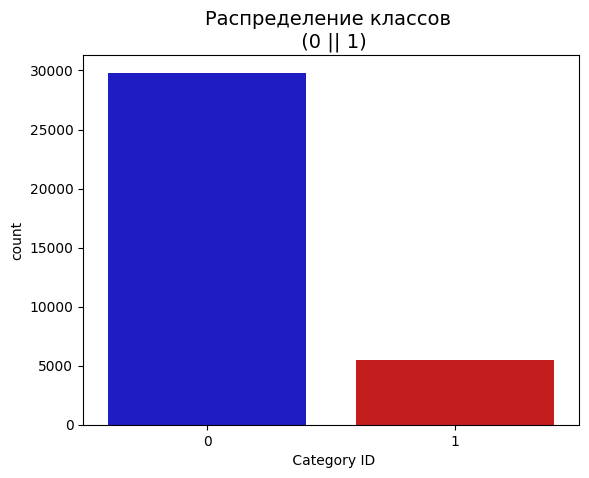

In [45]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x=' Category ID', data=dataset, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0 || 1)', fontsize=14)

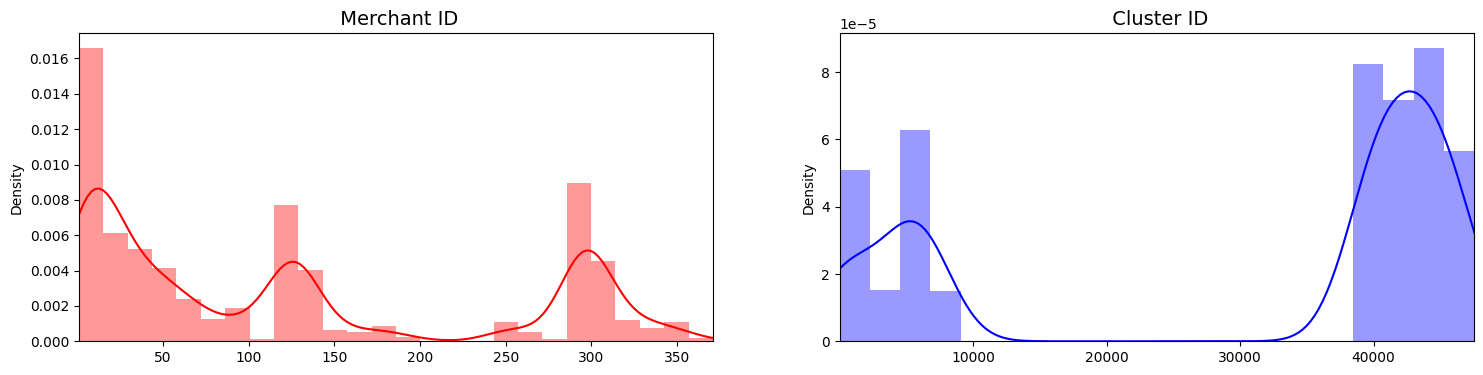

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

m = dataset[' Merchant ID'].values
cid = dataset[' Cluster ID'].values

sns.distplot(m, ax=ax[0], color='r')
ax[0].set_title(' Merchant ID', fontsize=14)
ax[0].set_xlim([min(m), max(m)])

sns.distplot(cid, ax=ax[1], color='b')
ax[1].set_title(' Cluster ID', fontsize=14)
ax[1].set_xlim([min(сid), max(сid)])

plt.show()

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [53]:
X = dataset.drop([' Category ID'], axis=1)
y = dataset[' Category ID']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (35311, 2) | y shape: (35311,) 


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=15)

Метод Random Under-Sampling

In [68]:
dfdf_train = X_train.copy()
df_train[' Category ID'] = y_train.values

# Теперь балансируем на тренировочных данных
df_train_shuffled = df_train.sample(frac=1)
o = df_train_shuffled[df_train_shuffled[' Category ID'] == 0][:len(v)]  # обрезаем класс 0 до размера класса 1
v = df_train_shuffled[df_train_shuffled[' Category ID'] == 1]
balanced_df = pd.concat([o, v])
final_df = balanced_df.sample(frac=1, random_state=42)

print(f"Размер final_df: {final_df.shape}")
print(f"Класс 0: {(final_df[' Category ID'] == 0).sum()}")
print(f"Класс 1: {(final_df[' Category ID'] == 1).sum()}")

Размер final_df: (6544, 3)
Класс 0: 3272
Класс 1: 3272


Text(0.5, 1.0, 'Распределение классов \n (0 || 1)')

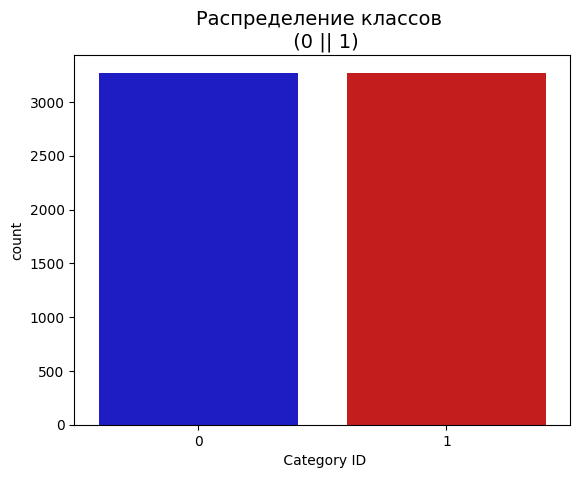

In [70]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x=' Category ID', data=final_df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0 || 1)', fontsize=14)

матрица корреляций

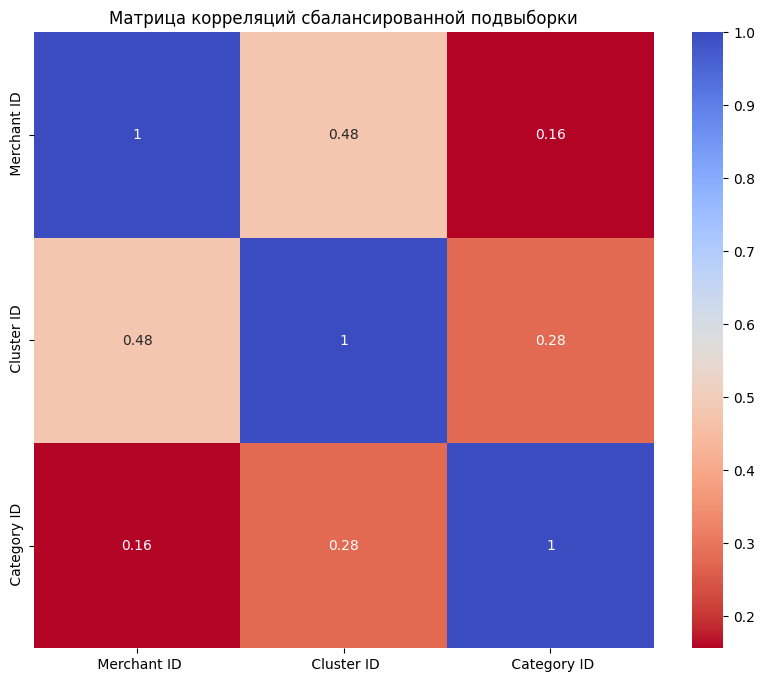

In [71]:
plt.figure(figsize=(10, 8))
sns.heatmap(new_df.corr(), cmap='coolwarm_r', annot=True)
plt.title('Матрица корреляций сбалансированной подвыборки')
plt.show()

теперь кластер хорошо коррелирует с продавцами

boxplot

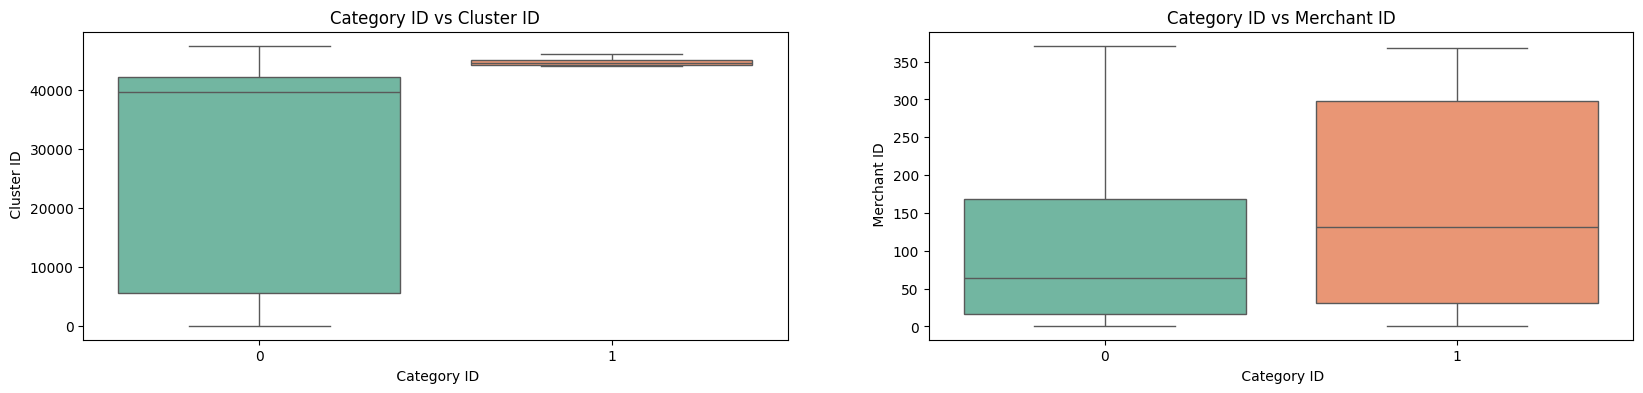

In [72]:
f, axes = plt.subplots(ncols=2, figsize=(20,4))

sns.boxplot(x=' Category ID', y=' Cluster ID', data=new_df, palette='Set2', ax=axes[0])
axes[0].set_title('Category ID vs Cluster ID')

sns.boxplot(x=' Category ID', y=' Merchant ID', data=new_df, palette='Set2', ax=axes[1])
axes[1].set_title('Category ID vs Merchant ID')

plt.show()

удаление выбросов

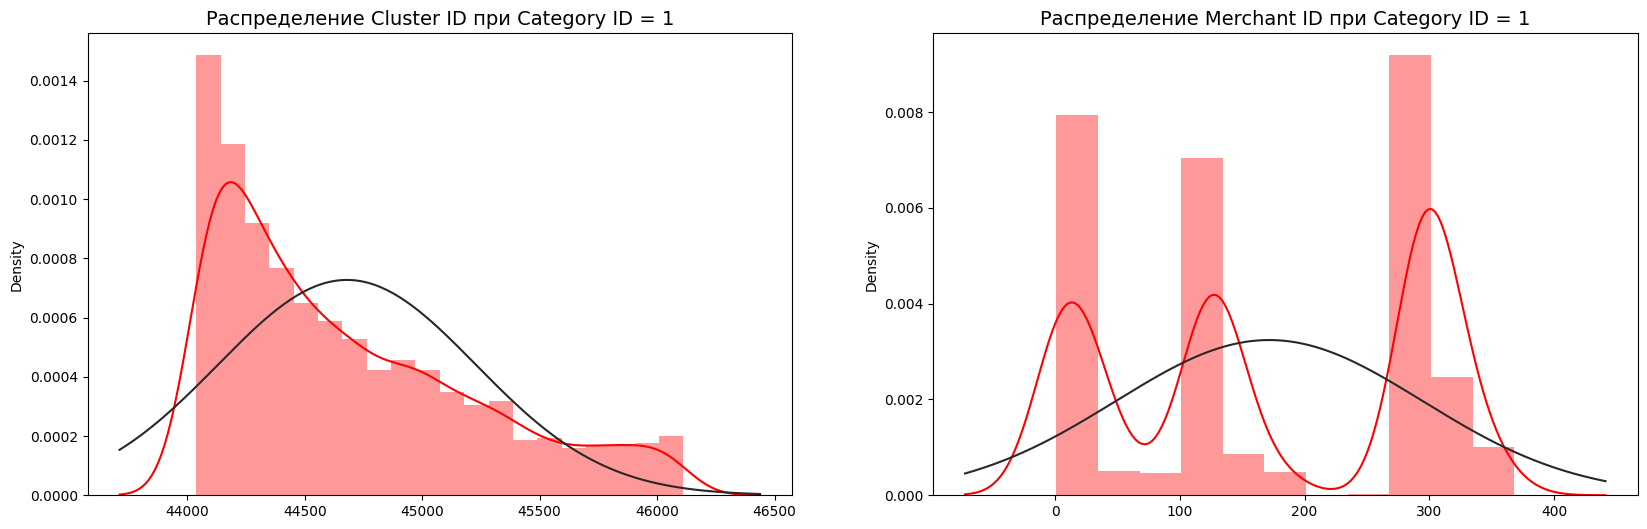

In [74]:
from scipy.stats import norm

f, (ax1, ax2) = plt.subplots(1,2, figsize=(20, 6))

####
s_dist = new_df[' Cluster ID'].loc[new_df[' Category ID'] == 1].values

sns.distplot(s_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение Cluster ID при Category ID = 1', fontsize=14)

####
r_dist = new_df[' Merchant ID'].loc[new_df[' Category ID'] == 1].values

sns.distplot(r_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение Merchant ID при Category ID = 1', fontsize=14)

plt.show()

In [76]:
s = new_df[' Cluster ID'].loc[new_df[' Category ID'] == 1].values
q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
s_iqr = q75 - q25
print('iqr: {}'.format(s_iqr))

s_cut_off = s_iqr * 1.5
s_lower, s_upper = q25 - s_cut_off, q75 + s_cut_off
print('Порог: {}'.format(s_cut_off))
print('s нижняя граница: {}'.format(s_lower))
print('s верхняя граница: {}'.format(s_upper))

outliers = [x for x in s if x < s_lower or x > s_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers = new_df.drop(new_df[(new_df[' Cluster ID'] > s_upper) | (new_df[' Cluster ID'] < s_lower)].index)
print('----' * 44)


r = new_df[' Merchant ID'].loc[new_df[' Category ID'] == 1].values
q25, q75 = np.percentile(r, 25), np.percentile(r, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
r_iqr = q75 - q25
print('iqr: {}'.format(r_iqr))

r_cut_off = r_iqr * 1.5
r_lower, r_upper = q25 - r_cut_off, q75 + r_cut_off
print('Порог: {}'.format(r_cut_off))
print('r нижняя граница: {}'.format(r_lower))
print('r верхняя граница: {}'.format(r_upper))

outliers = [x for x in r if x < r_lower or x > r_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers = new_df.drop(new_df[(new_df[' Merchant ID'] > r_upper) | (new_df[' Merchant ID'] < r_lower)].index)
print('----' * 44)

Квартиль 25: 44220.0 | Квартиль 75: 45021.25
iqr: 801.25
Порог: 1201.875
s нижняя граница: 43018.125
s верхняя граница: 46223.125
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 31.0 | Квартиль 75: 298.0
iqr: 267.0
Порог: 400.5
r нижняя граница: -369.5
r верхняя граница: 698.5
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [77]:
new_df = new_df_without_outliers

понижение размерности и кластеризация

In [80]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import time

X = new_df.drop(' Category ID', axis=1)
y = new_df[' Category ID']

In [ ]:
# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

зависает

In [82]:
# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

PCA заняло 0.018 сек


In [83]:
# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

Truncated SVD заняло 0.033 сек


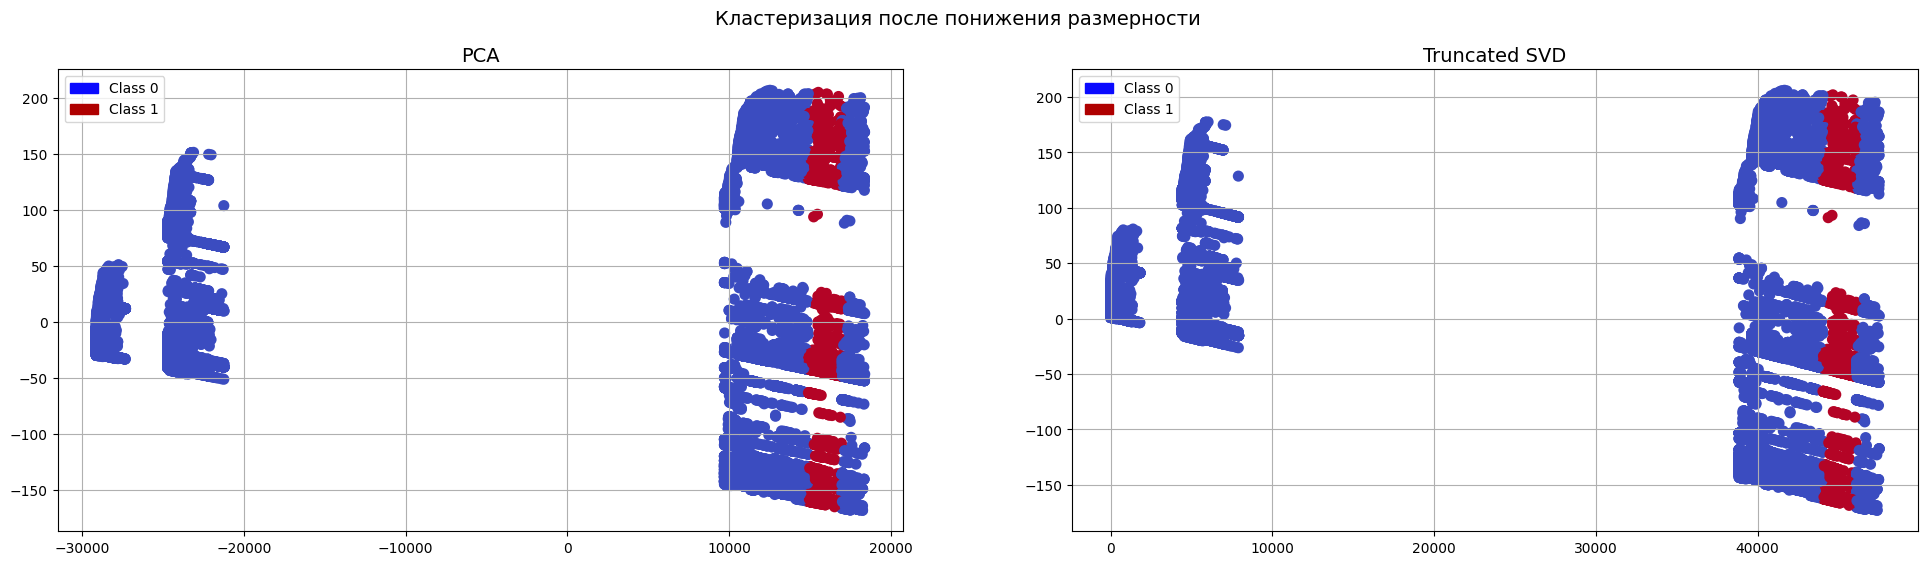

In [90]:
f, (ax2, ax3) = plt.subplots(1, 2, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)

blue_patch = mpatches.Patch(color='#0A0AFF', label='Class 0')
red_patch = mpatches.Patch(color='#AF0000', label='Class 1')

# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=y, cmap='coolwarm', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=y, cmap='coolwarm', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])

plt.show()

ну классы различимы

часть 2

In [92]:
final_df

,Merchant ID,Cluster ID,Category ID
18899,324,41047,0
19879,324,41769,0
2531,24,559,0
32172,130,46169,0
26828,294,44100,1
...,...,...,...
31644,324,46026,1
28875,6,44491,1
30445,134,45069,1
29643,125,44740,1


In [93]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0
...,...,...,...
35306,59,47517,0
35307,59,47518,0
35308,59,47519,0
35309,125,47524,0


дальнейшая работа проводится с маленьким датасетом

In [95]:
# Твой датасет - final_df
X = final_df.drop(' Category ID', axis=1)
y = final_df[' Category ID']

# Разделение на train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

classifiers = {
    "LogisticRegression": LogisticRegression(),
    "SVC": SVC(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

# Оценка
from sklearn.model_selection import cross_val_score

for key, classifier in classifiers.items():
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f"Модель {key} получила на обучающей выборке {round(training_score.mean() * 100, 2)}% accuracy score")

Модель LogisticRegression получила на обучающей выборке 89.96% accuracy score
Модель SVC получила на обучающей выборке 88.56% accuracy score
Модель KNeighborsClassifier получила на обучающей выборке 99.78% accuracy score
Модель DecisionTreeClassifier получила на обучающей выборке 100.0% accuracy score


In [98]:
# Используем поиск по сетке для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Логистическая регрессия
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)

# Выбираем лучшую модель
log_reg = grid_log_reg.best_estimator_ #  для Логистическая регрессия

# Метод ближайших соседей
knears_params = {"n_neighbors": list(range(2,7,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)

knears_neighbors = grid_knears.best_estimator_# для  K ближайший соседей

# Решающее дерево
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,7,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

tree_clf = grid_tree.best_estimator_#  для решающий деревьев

вектора зависают

In [99]:
# Проверим, как поменялись метрики

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  89.96%
Knears Neighbors Cross Validation Score 99.8%
DecisionTree Classifier Cross Validation Score 100.0%


ничего не поменялось, все так, как и было

In [101]:
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from collections import Counter

rob_scaler = RobustScaler()

skf = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

from sklearn.metrics import (precision_score, roc_auc_score, recall_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve, accuracy_score)

# Используем final_df
undersample_X = final_df.drop(' Category ID', axis=1)
undersample_y = final_df[' Category ID']

undersample_Xtrain, undersample_Xtest, undersample_ytrain, undersample_ytest = train_test_split(undersample_X, undersample_y,
                                                                                                test_size=0.2,
                                                                                                random_state=42,
                                                                                                stratify=undersample_y)

# Не преобразовываем в values сразу, оставляем как DataFrame для совместимости

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Логистическая регрессия
log_reg = LogisticRegression(random_state=42)

# Метод NearMiss
X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss распределение классов: {}'.format(Counter(y_nearmiss)))

for train, test in skf.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg)
    undersample_model = undersample_pipeline.fit(undersample_Xtrain.iloc[train], undersample_ytrain.iloc[train])
    undersample_prediction = undersample_model.predict(undersample_Xtrain.iloc[test])

    undersample_accuracy.append(accuracy_score(undersample_ytrain.iloc[test], undersample_prediction))
    undersample_precision.append(precision_score(undersample_ytrain.iloc[test], undersample_prediction))
    undersample_recall.append(recall_score(undersample_ytrain.iloc[test], undersample_prediction))
    undersample_f1.append(f1_score(undersample_ytrain.iloc[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(undersample_ytrain.iloc[test], undersample_prediction))

print(f"\nРезультаты NearMiss:")
print(f"Accuracy: {np.mean(undersample_accuracy):.4f}")
print(f"Precision: {np.mean(undersample_precision):.4f}")
print(f"Recall: {np.mean(undersample_recall):.4f}")
print(f"F1: {np.mean(undersample_f1):.4f}")
print(f"AUC: {np.mean(undersample_auc):.4f}")

NearMiss распределение классов: Counter({np.int64(0): 3272, np.int64(1): 3272})

Результаты NearMiss:
Accuracy: 0.9005
Precision: 0.8341
Recall: 1.0000
F1: 0.9095
AUC: 0.9005


модель хорошо находит 1 класс, но иногда 0 путает с 1

In [102]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve
import seaborn as sn

кривая обучения

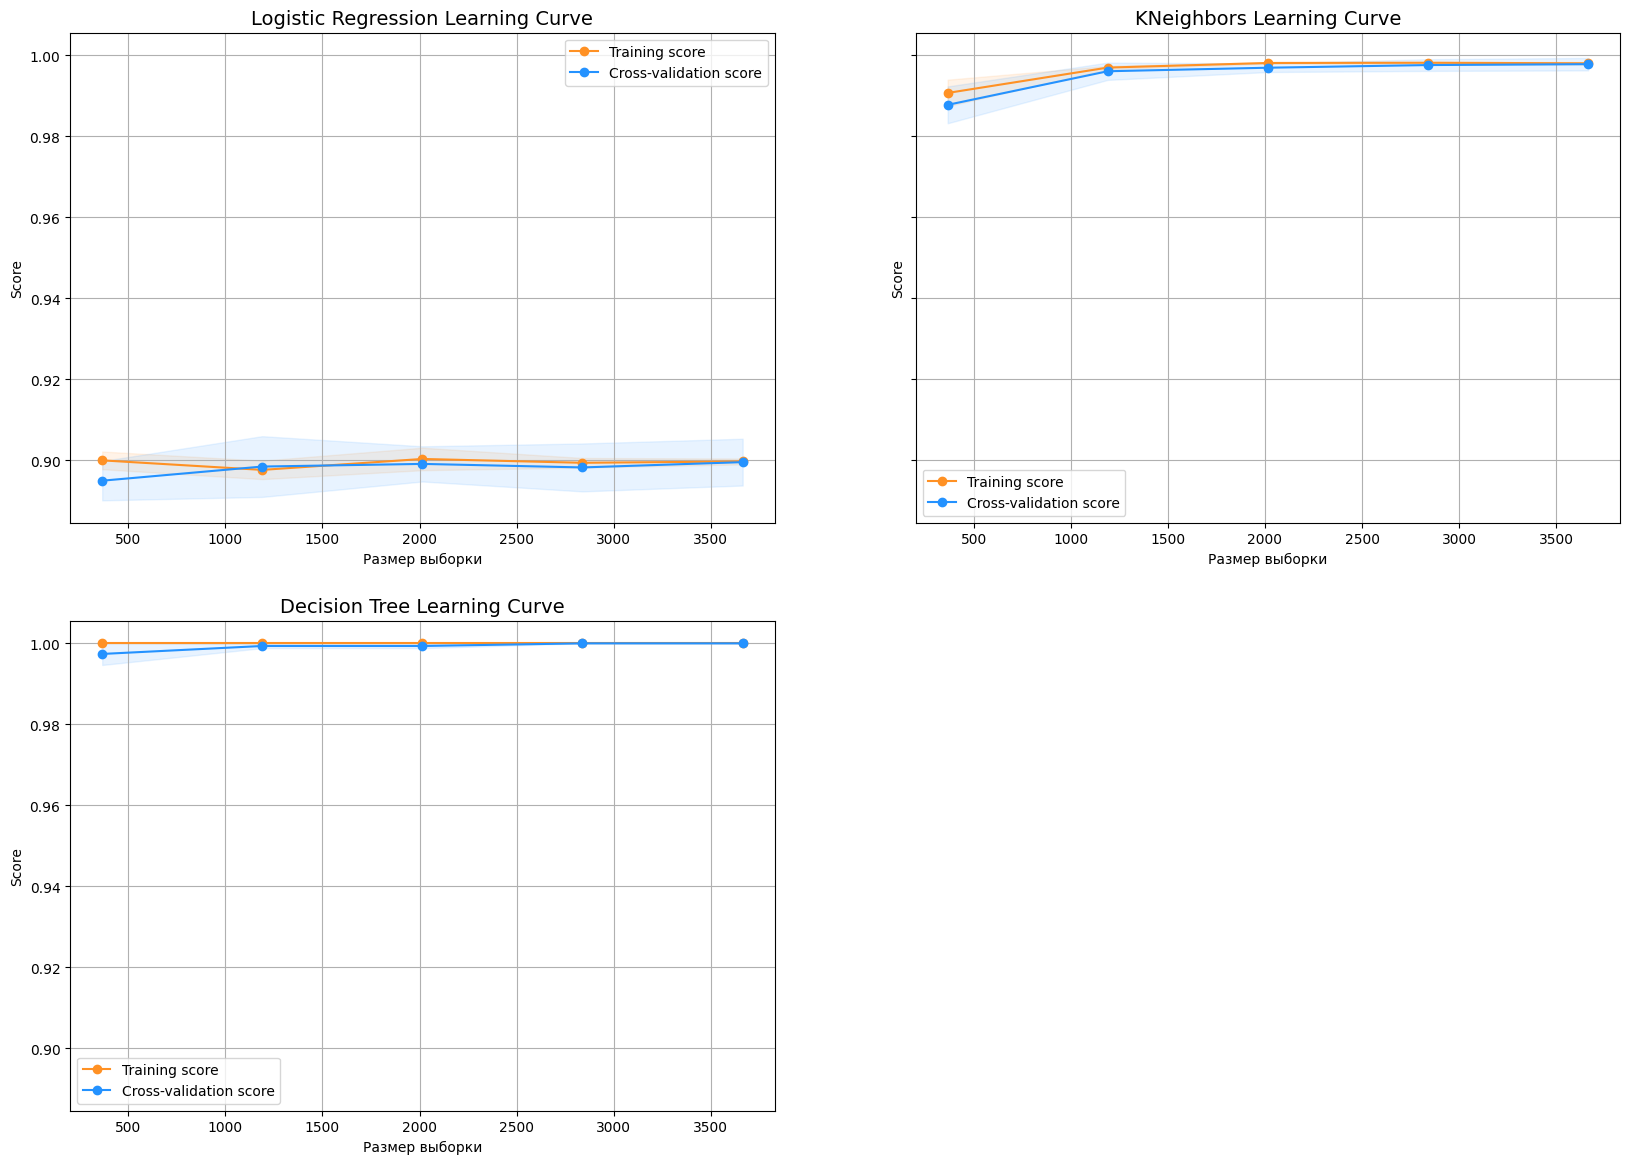

In [104]:
def plot_learning_curves(estimator1, estimator2, estimator3, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)

    # Первая модель - Logistic Regression
    train_sizes, train_scores, test_scores = learning_curve(estimator1, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Размер выборки')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Вторая модель - KNeighbors
    train_sizes, train_scores, test_scores = learning_curve(estimator2, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("KNeighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Размер выборки')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")

    # Третья модель - Decision Tree
    train_sizes, train_scores, test_scores = learning_curve(estimator3, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Decision Tree Learning Curve", fontsize=14)
    ax3.set_xlabel('Размер выборки')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")

    # Убираем четвёртый график, т.к векторы зависли
    ax4.axis('off')

    return plt
log_reg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
plot_learning_curves(log_reg, knn, dt, X_train, y_train, cv=5)
plt.show()

график потряхивает, ну лучше всего выглядит регрессия, она в районе 90%

In [106]:
from sklearn.model_selection import cross_val_predict

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [107]:
print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.8731381422727421
KNears Neighbors:  0.9980314480136752
Decision Tree Classifier:  1.0


SMOTE метод (Over-Sampling)

In [111]:
from sklearn.model_selection import train_test_split
import numpy as np

# Используем dataset (большой датасет)
X = dataset.drop(' Category ID', axis=1)
y = dataset[' Category ID']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state=42)

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор:", test_counts_label / len(original_ytest))
print(f"\nРазмер обучающей выборки: {len(original_Xtrain)}")
print(f"Размер тестовой выборки: {len(original_Xtest)}")

Распределение классов: 

Обучающий набор: [0.84473237 0.15526763]
Тестовый набор: [0.84213507 0.15786493]

Размер обучающей выборки: 28248
Размер тестовой выборки: 7063


In [113]:
tuned_classifiers = {
    "LogisiticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    "DecisionTreeClassifier": tree_clf
}

#Making our Classifiers train with the tuned parameters
for key, classifier in tuned_classifiers.items():
    score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f'{key} Cross Validation Score: {round(score.mean() * 100, 2)}%')

LogisiticRegression Cross Validation Score: 89.96%
Knears Neighbors Cross Validation Score: 99.8%
DecisionTreeClassifier Cross Validation Score: 100.0%


In [118]:
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from imblearn.over_sampling import SMOTE

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for key, classifier in tuned_classifiers.items():
    # Pipeline из imblearn
    steps = [('sampler', SMOTE(sampling_strategy='auto', k_neighbors=5)), ('model', classifier)]

    FiPipeline = Pipeline(steps=steps)
    scores = cross_val_score(FiPipeline, X, y, cv=sss)
    print(f"Classifiers: {key} has a training score of {round(scores.mean() * 100, 2)}% accuracy score")

Classifiers: LogisiticRegression has a training score of 82.85% accuracy score
Classifiers: Knears Neighbors has a training score of 99.97% accuracy score
Classifiers: DecisionTreeClassifier has a training score of 100.0% accuracy score


я верю логистической модели

In [120]:
from imblearn.under_sampling import RandomUnderSampler
# Сначала посмотрим распределение классов
print("Распределение классов в y:")
print(y.value_counts())
minority_count = y.value_counts().min()
majority_count = y.value_counts().max()
print(f"Миноритарный класс: {minority_count} образцов")
print(f"Мажоритарный класс: {majority_count} образцов")

# Параметры для SMOTE и UnderSampling
smote_strategy = 0.5
under_strategy = 0.8

# Разделяем данные
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(X, y):
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]
    break

# Логистическая регрессия
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Pipeline
model = Pipeline([
    ('sampling', SMOTE(sampling_strategy=smote_strategy, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)),
    ('classification', log_reg)
])

# GridSearchCV для подбора k_neighbors
SMOTE_KN = GridSearchCV(model, {'sampling__k_neighbors': list(range(2, 10))}, cv=3, scoring='f1')
SMOTE_KN.fit(original_Xtrain, original_ytrain)

print(f"\nЛучший estimator: {SMOTE_KN.best_estimator_}")
print(f"Лучший score: {SMOTE_KN.best_score_:.4f}")
print(f"Лучшие параметры: {SMOTE_KN.best_params_}")

# Оценка модели
log_reg_score = cross_val_score(SMOTE_KN.best_estimator_, original_Xtrain, original_ytrain, cv=3, scoring='f1')

print(f"\nLogistic Regression Cross Validation Score: {round(log_reg_score.mean() * 100, 2)}%")

Распределение классов в y:
 Category ID
0    29810
1     5501
Name: count, dtype: int64
Миноритарный класс: 5501 образцов
Мажоритарный класс: 29810 образцов

Лучший estimator: Pipeline(steps=[('sampling',
                 SMOTE(k_neighbors=9, random_state=42, sampling_strategy=0.5)),
                ('under',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.8)),
                ('classification',
                 LogisticRegression(max_iter=1000, random_state=42))])
Лучший score: 0.6771
Лучшие параметры: {'sampling__k_neighbors': 9}

Logistic Regression Cross Validation Score: 67.71%


вполне реалистичный результат

In [121]:
labels = ['0', '1']

best_est = SMOTE_KN.best_estimator_
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names=labels))

              precision    recall  f1-score   support

           0       1.00      0.81      0.90      5963
           1       0.50      1.00      0.66      1100

    accuracy                           0.84      7063
   macro avg       0.75      0.91      0.78      7063
weighted avg       0.92      0.84      0.86      7063



модель нашла все единички, каждый второй названный ею единичкой объект оказывается реально 1

In [122]:
y_score = best_est.decision_function(original_Xtest)

In [123]:
sm = SMOTE(sampling_strategy='minority', random_state=42)

# Применим SMOTE после кросс-валидации
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

In [124]:
# Обучим логистическую регрессию
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Время обучения: {} сек".format(t1 - t0))

Время обучения: 0.20399260520935059 сек


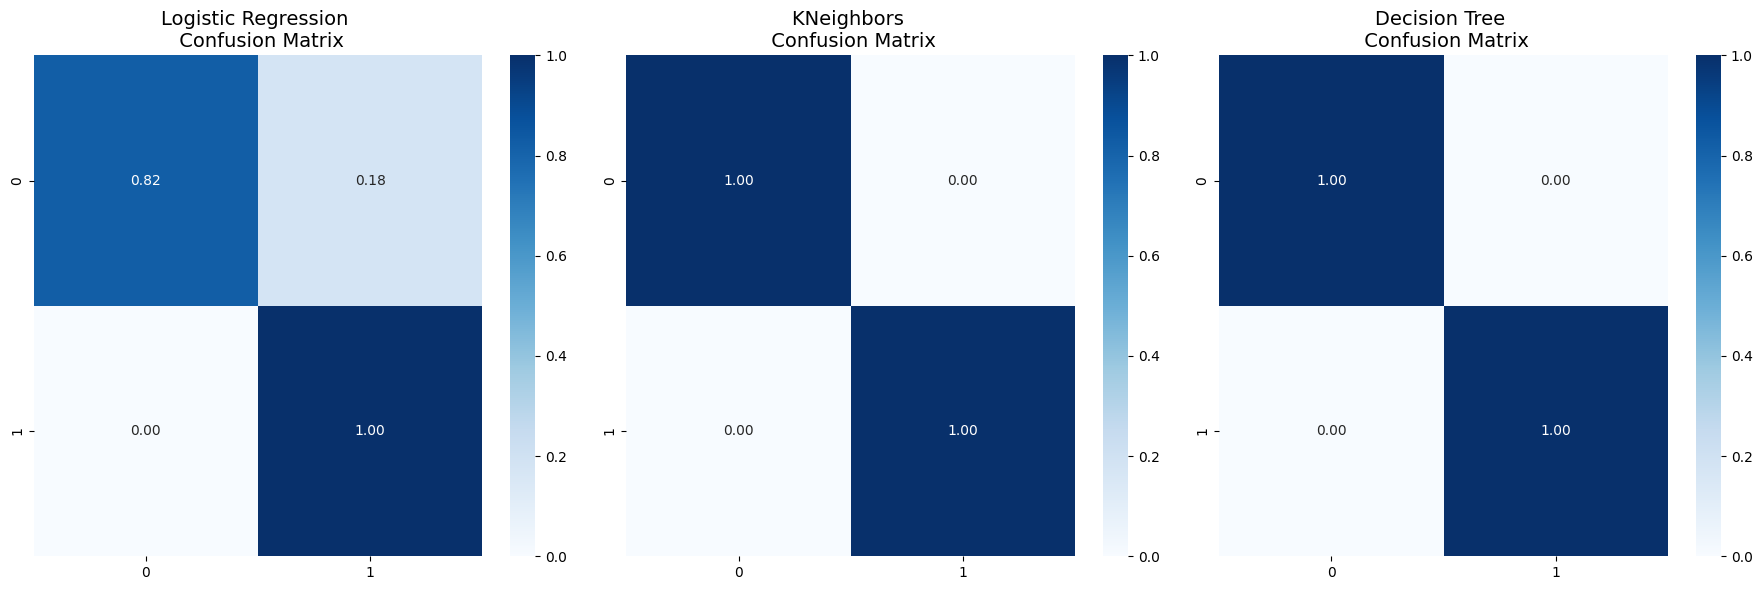

In [125]:
y_pred_log_reg = best_est.predict(X_test)
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)

log_reg_cf = confusion_matrix(y_test, y_pred_log_reg, normalize='true')
kneighbors_cf = confusion_matrix(y_test, y_pred_knear, normalize='true')
tree_cf = confusion_matrix(y_test, y_pred_tree, normalize='true')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression
sns.heatmap(ax=ax1, data=log_reg_cf, annot=True, fmt='.2f', cmap='Blues')
ax1.set_title("Logistic Regression \n Confusion Matrix", fontsize=14)

# KNeighbors
sns.heatmap(ax=ax2, data=kneighbors_cf, annot=True, fmt='.2f', cmap='Blues')
ax2.set_title("KNeighbors \n Confusion Matrix", fontsize=14)

# Decision Tree
sns.heatmap(ax=ax3, data=tree_cf, annot=True, fmt='.2f', cmap='Blues')
ax3.set_title("Decision Tree \n Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

регрессия выглядит правдоподобно

метрики

In [126]:
from sklearn.metrics import classification_report

print('Logistic Regression:')
#
y_pred=  best_est.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('KNears Neighbors:')
#
y_pred=  knears_neighbors.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('Decision Tree Classifier:')
#
y_pred=  tree_clf.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90      5963
           1       0.50      1.00      0.66      1100

    accuracy                           0.84      7063
   macro avg       0.75      0.91      0.78      7063
weighted avg       0.92      0.84      0.86      7063

KNears Neighbors:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5963
           1       0.99      1.00      1.00      1100

    accuracy                           1.00      7063
   macro avg       1.00      1.00      1.00      7063
weighted avg       1.00      1.00      1.00      7063

Decision Tree Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5963
           1       1.00      1.00      1.00      1100

    accuracy                           1.00      7063
   macro avg       1.00      1.00      1.00      7063
weighted 

In [128]:
log_reg.fit(original_Xtrain, original_ytrain)

y_pred = log_reg.predict(original_Xtest)
undersample_score = accuracy_score(original_ytest, y_pred)

In [129]:
# Логистическая регрессия с under-sampling
y_pred = log_reg.predict(original_Xtest)
undersample_score = accuracy_score(original_ytest, y_pred)

# Логистическая регрессия с over-sampling
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)

d = {'Метод': ['Random Under-Sampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

final_df

,Метод,Score
0,Random Under-Sampling,0.737505
1,Oversampling (SMOTE),0.842418


второй метод оказался лучше

часть 3

In [131]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["0", "1"]

In [132]:
print(df.shape)
print(df.describe())

(35311, 3)
        Merchant ID    Cluster ID   Category ID
count  35311.000000  35311.000000  35311.000000
mean     120.501883  30110.687633      0.155787
std      117.045557  18410.265642      0.362659
min        1.000000      1.000000      0.000000
25%       17.000000   6123.000000      0.000000
50%       75.000000  40630.000000      0.000000
75%      253.000000  44059.000000      0.000000
max      371.000000  47525.000000      1.000000


пропуски

In [133]:
df.isnull().values.any()

np.False_

In [136]:
df[' Category ID'].value_counts()

,count
Category ID,
0,29810
1,5501


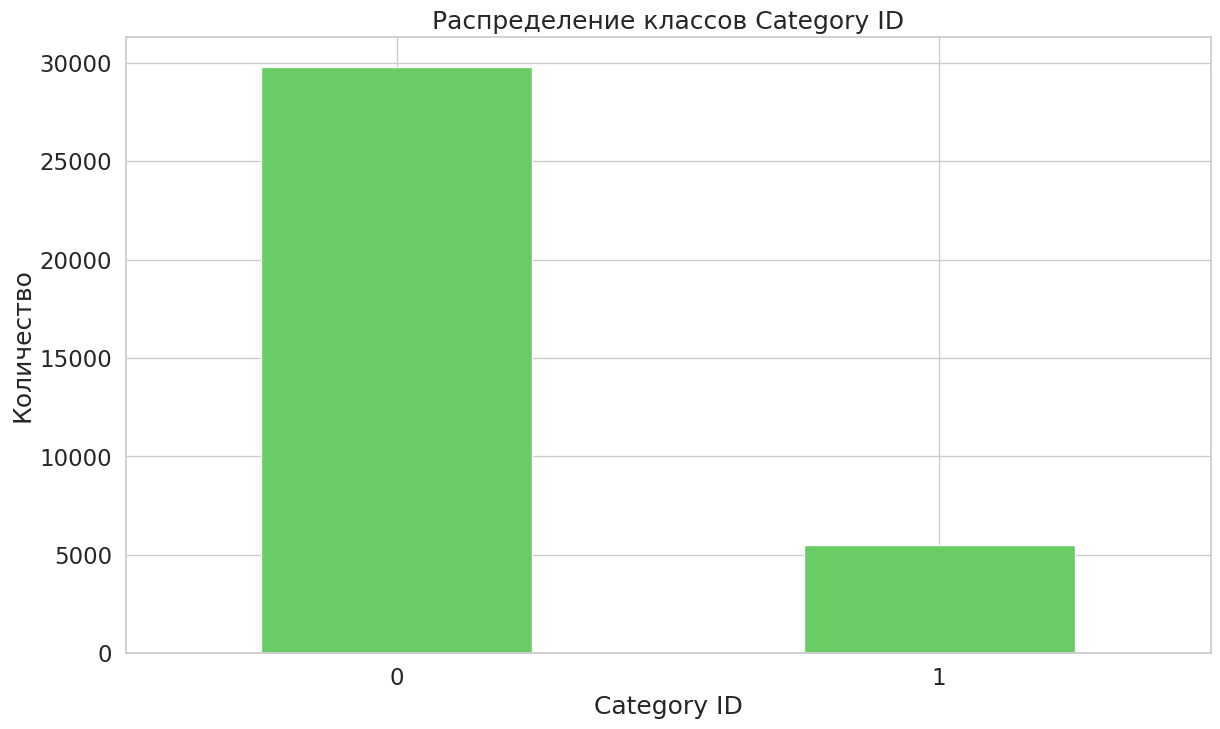

In [138]:
count_classes = pd.value_counts(df[' Category ID'], sort=True)
count_classes.plot(kind='bar', rot=0, color='g')
plt.title("Распределение классов Category ID")
plt.xticks(range(2), ['0', '1'])
plt.xlabel("Category ID")
plt.ylabel("Количество")
plt.show()

In [141]:
o = df[df[' Category ID'] == 0]
v = df[df[' Category ID'] == 1]

In [142]:
o.shape

(29810, 3)

In [143]:
v.shape

(5501, 3)

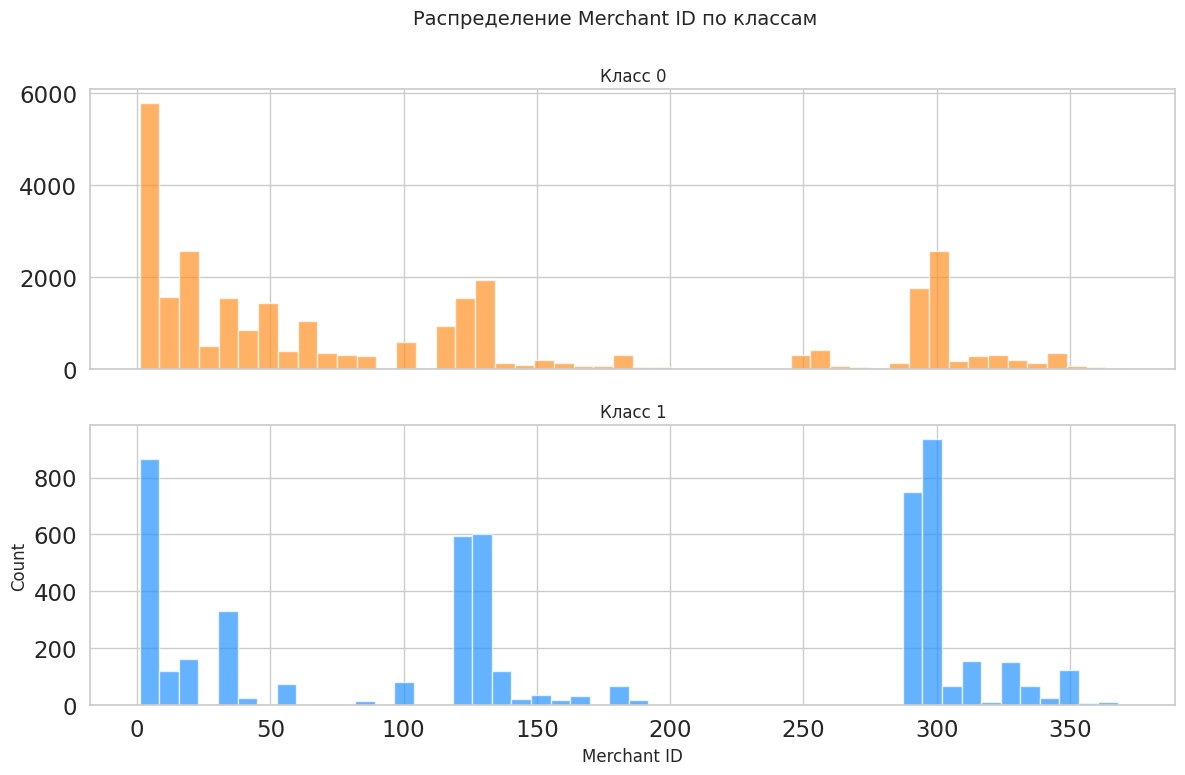

In [146]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Распределение Merchant ID по классам', fontsize=14)

bins = 50

ax1.hist(o[' Merchant ID'], bins=bins, color='#ff9124', alpha=0.7)
ax1.set_title('Класс 0', fontsize=12)

ax2.hist(v[' Merchant ID'], bins=bins, color='#2492ff', alpha=0.7)
ax2.set_title('Класс 1', fontsize=12)

plt.xlabel('Merchant ID', size=12)
plt.ylabel('Count', size=12)
plt.show()

продавцы равномерно распределены довольно

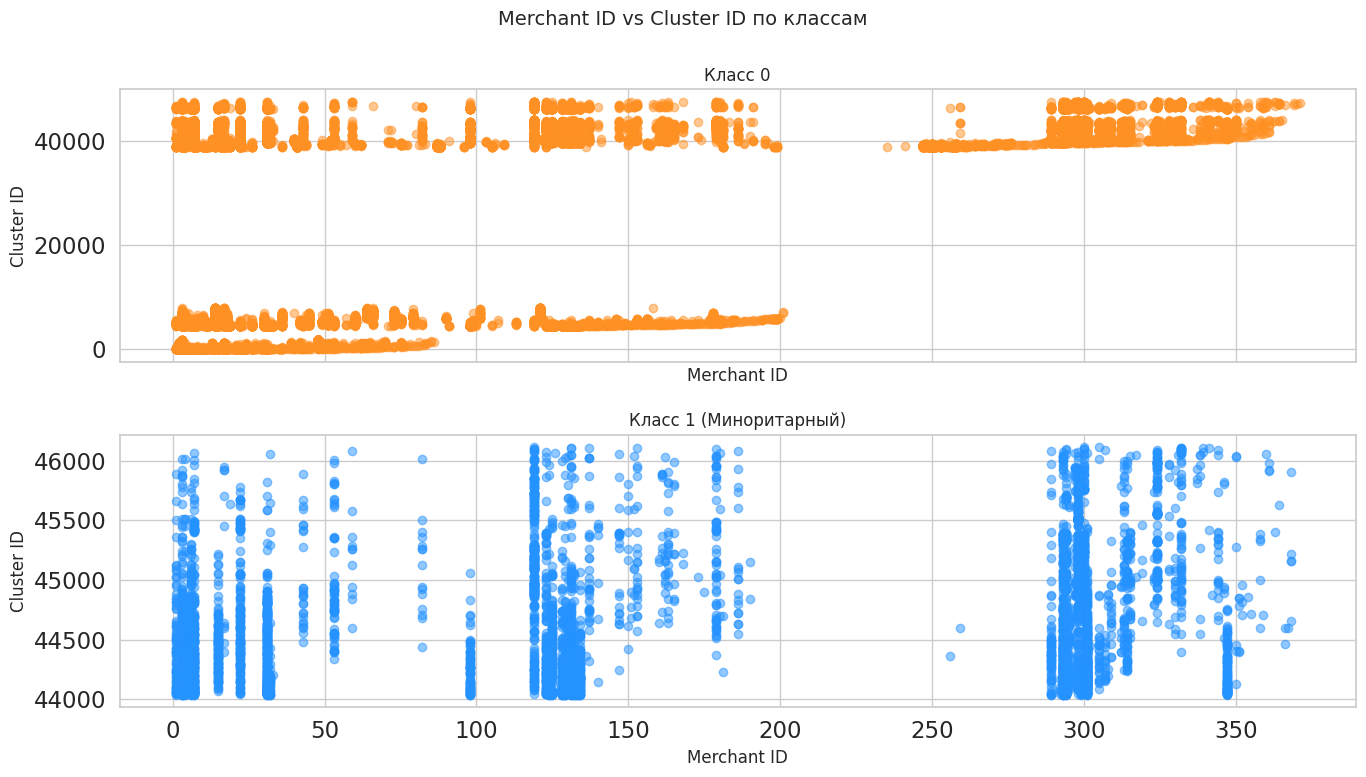

In [147]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Merchant ID vs Cluster ID по классам', fontsize=14)

ax1.scatter(o[' Merchant ID'], o[' Cluster ID'], alpha=0.5, color='#ff9124')
ax1.set_title('Класс 0', fontsize=12)
ax1.set_xlabel('Merchant ID', size=12)
ax1.set_ylabel('Cluster ID', size=12)

ax2.scatter(v[' Merchant ID'], v[' Cluster ID'], alpha=0.5, color='#2492ff')
ax2.set_title('Класс 1 (Миноритарный)', fontsize=12)
ax2.set_xlabel('Merchant ID', size=12)
ax2.set_ylabel('Cluster ID', size=12)

plt.tight_layout()
plt.show()

единичка равномернее

In [161]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Подготовка данных
X_normal = dataset[dataset[' Category ID'] == 0][[' Merchant ID', ' Cluster ID']].values
X_normal = torch.FloatTensor(X_normal)

train_dataset = TensorDataset(X_normal)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Модель
class Autoencoder(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=1):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        encoded = torch.relu(self.encoder(x))
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder(input_dim=2, hidden_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 50
history = {'train_loss': []}

# Обучение
for epoch in range(num_epochs):
    h = []
    for batch in train_loader:
        data = batch[0]

        output = model(data)
        loss = criterion(output, data)
        h.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_loss = np.mean(h)
    print(f'epoch [{epoch + 1}/{num_epochs}], loss: {mean_loss:.4f}')
    history['train_loss'].append(mean_loss)

torch.save(model.state_dict(), './autoencoder_model.pth')

epoch [1/50], loss: 110547560.1373
epoch [2/50], loss: 5405.5436
epoch [3/50], loss: 5492.8675
epoch [4/50], loss: 5497.7144
epoch [5/50], loss: 5678.3015
epoch [6/50], loss: 6178.3747
epoch [7/50], loss: 5943.4741
epoch [8/50], loss: 5926.7964
epoch [9/50], loss: 5862.4027
epoch [10/50], loss: 6319.3790
epoch [11/50], loss: 6023.9941
epoch [12/50], loss: 6191.9835
epoch [13/50], loss: 6105.1474
epoch [14/50], loss: 6102.3960
epoch [15/50], loss: 6972.6681
epoch [16/50], loss: 5898.7256
epoch [17/50], loss: 6267.6984
epoch [18/50], loss: 6378.7427
epoch [19/50], loss: 6361.5314
epoch [20/50], loss: 5733.7490
epoch [21/50], loss: 5939.5234
epoch [22/50], loss: 6337.0943
epoch [23/50], loss: 6035.3800
epoch [24/50], loss: 6100.8951
epoch [25/50], loss: 6242.4464
epoch [26/50], loss: 6164.2465
epoch [27/50], loss: 6157.7538
epoch [28/50], loss: 6392.1945
epoch [29/50], loss: 6163.7788
epoch [30/50], loss: 5993.5226
epoch [31/50], loss: 6179.9965
epoch [32/50], loss: 6171.9433
epoch [33/50

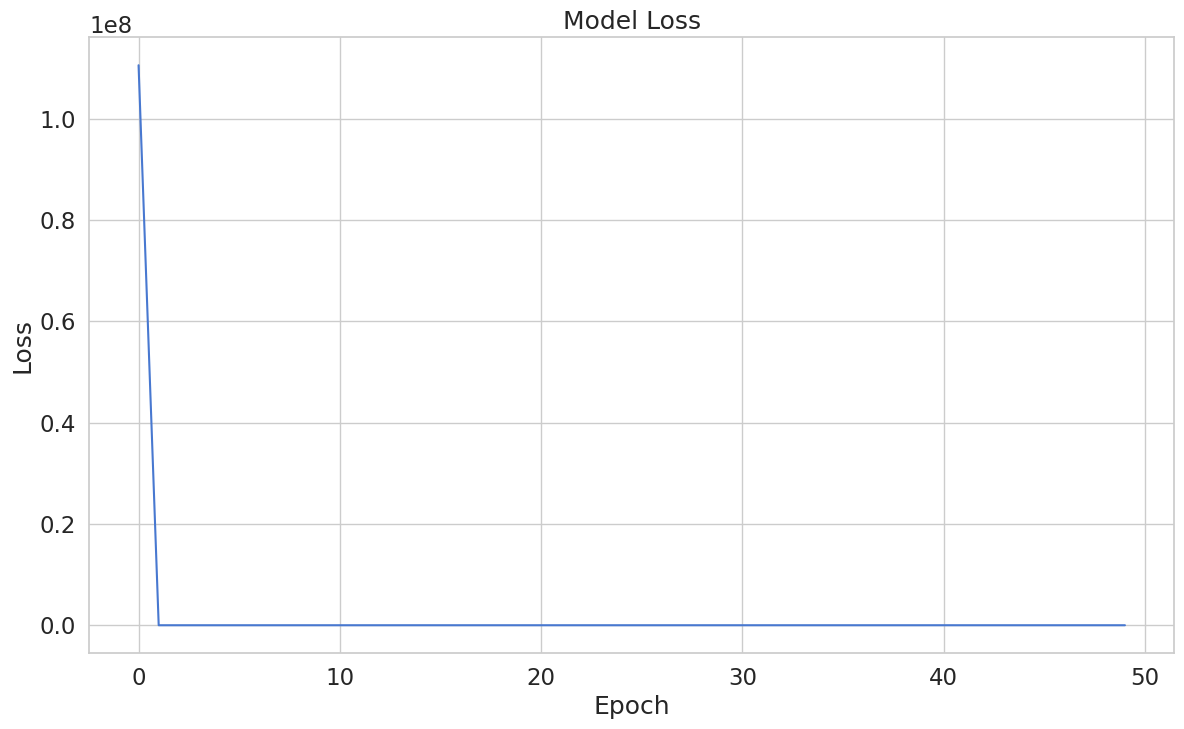

In [162]:
plt.plot(history['train_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [163]:
pred_losses = {'pred_loss': []}
model.eval()

with torch.no_grad():
    for data in test_loader:
        inputs = data[0].float()  # преобразуем в float
        outputs = model(inputs)
        loss = criterion(outputs, inputs).item()
        pred_losses['pred_loss'].append(loss)

reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['Category ID'] = y_test.values if hasattr(y_test, 'values') else y_test

print(reconstructionErrorDF.head())

      pred_loss  Category ID
0  19071.220703            0
1   8261.367188            0
2   6579.445801            0
3     41.406250            0
4  25246.962891            0


In [164]:
reconstructionErrorDF.describe()

,pred_loss,Category ID
count,7063.000000,7063.000000
mean,7094.414832,0.147671
std,8748.593996,0.354799
min,0.025832,0.000000
25%,971.641632,0.000000
50%,2889.222656,0.000000
75%,8201.425781,0.000000
max,30651.035156,1.000000


графики

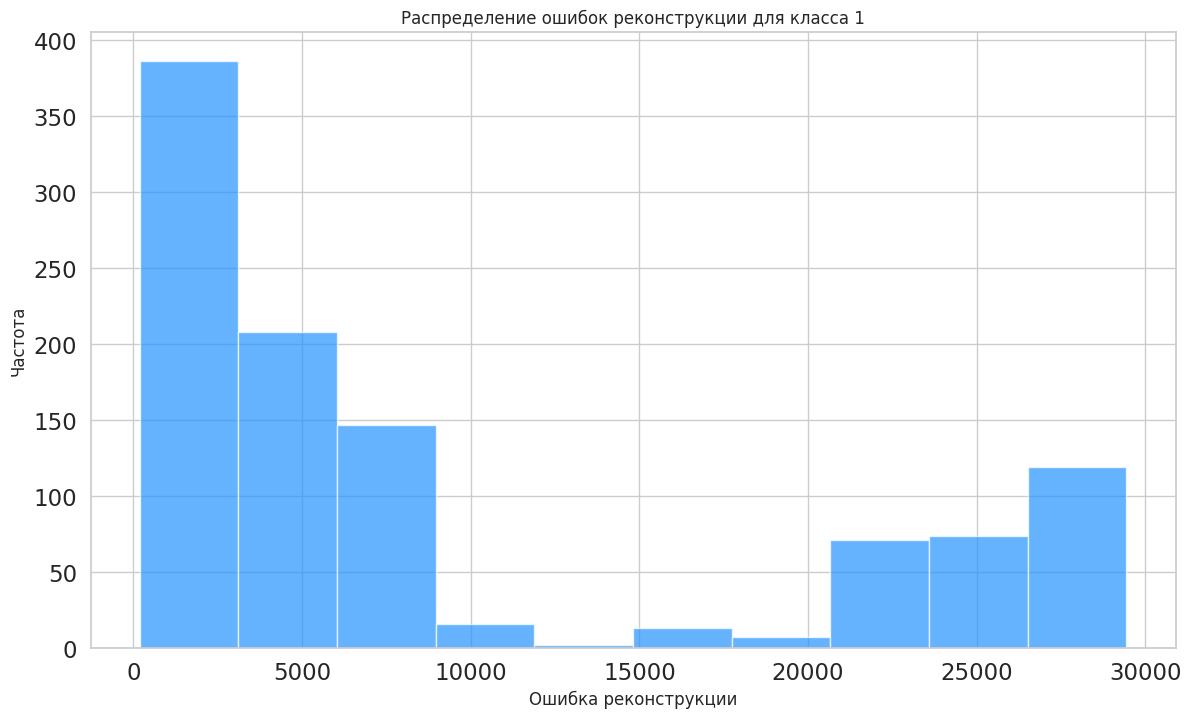

In [169]:
if 1 in reconstructionErrorDF['Category ID'].values:
    normal_error_df = reconstructionErrorDF[reconstructionErrorDF['Category ID'] == 1]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    _ = ax.hist(normal_error_df.pred_loss.values, bins=10, color='#2492ff', alpha=0.7)
    plt.title('Распределение ошибок реконструкции для класса 1', fontsize=12)
    plt.xlabel('Ошибка реконструкции', size=12)
    plt.ylabel('Частота', size=12)
    plt.show()
else:
    print("Класс 1 не найден в данных")

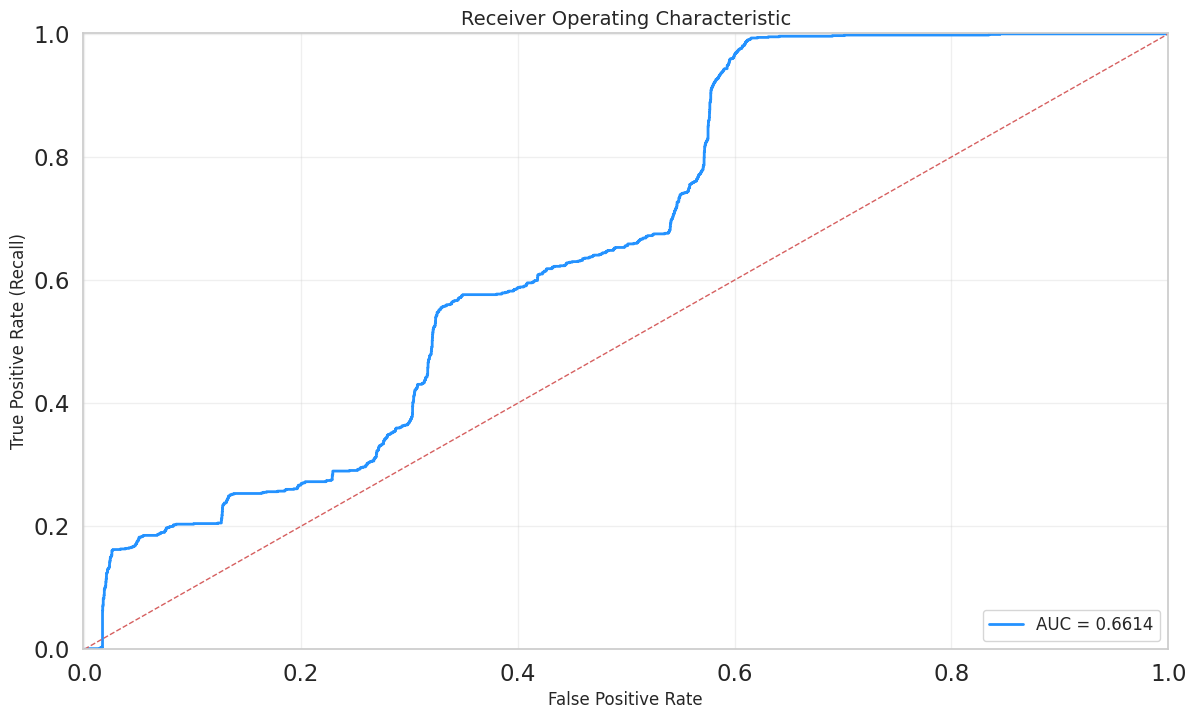

AUC Score: 0.6614


In [171]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(reconstructionErrorDF['Category ID'],
                                  reconstructionErrorDF['pred_loss'],
                                  pos_label=1)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic', fontsize=14)
plt.plot(fpr, tpr, label='AUC = %0.4f' % roc_auc, color='#2492ff', linewidth=2)
plt.legend(loc='lower right', fontsize=12)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate (Recall)', size=12)
plt.xlabel('False Positive Rate', size=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f'AUC Score: {roc_auc:.4f}')

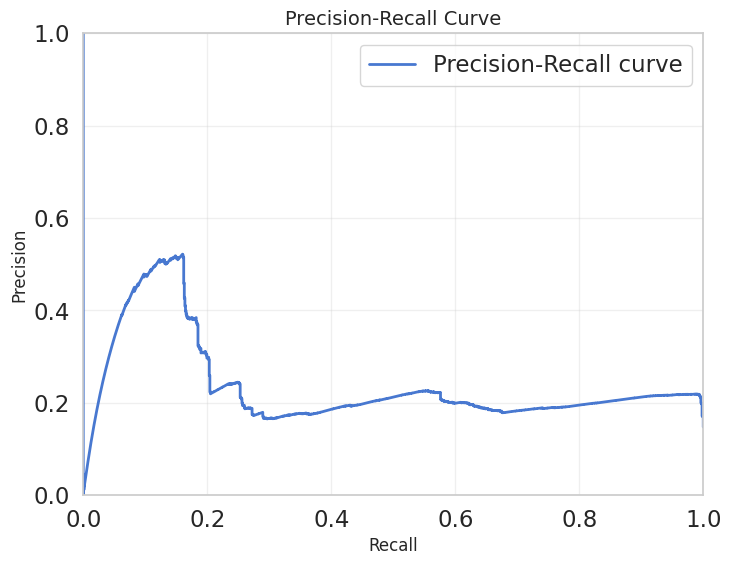

Average Precision (AP): 0.2360


In [173]:
from sklearn.metrics import precision_recall_curve

precision, recall, th = precision_recall_curve(reconstructionErrorDF['Category ID'],
                                                reconstructionErrorDF['pred_loss'],
                                                pos_label=1)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, 'b-', linewidth=2, label='Precision-Recall curve')
plt.title('Precision-Recall Curve', fontsize=14)
plt.xlabel('Recall', size=12)
plt.ylabel('Precision', size=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

# Можно также посчитать площадь под кривой (Average Precision)
from sklearn.metrics import average_precision_score
ap_score = average_precision_score(reconstructionErrorDF['Category ID'],
                                    reconstructionErrorDF['pred_loss'],
                                    pos_label=1)
print(f'Average Precision (AP): {ap_score:.4f}')

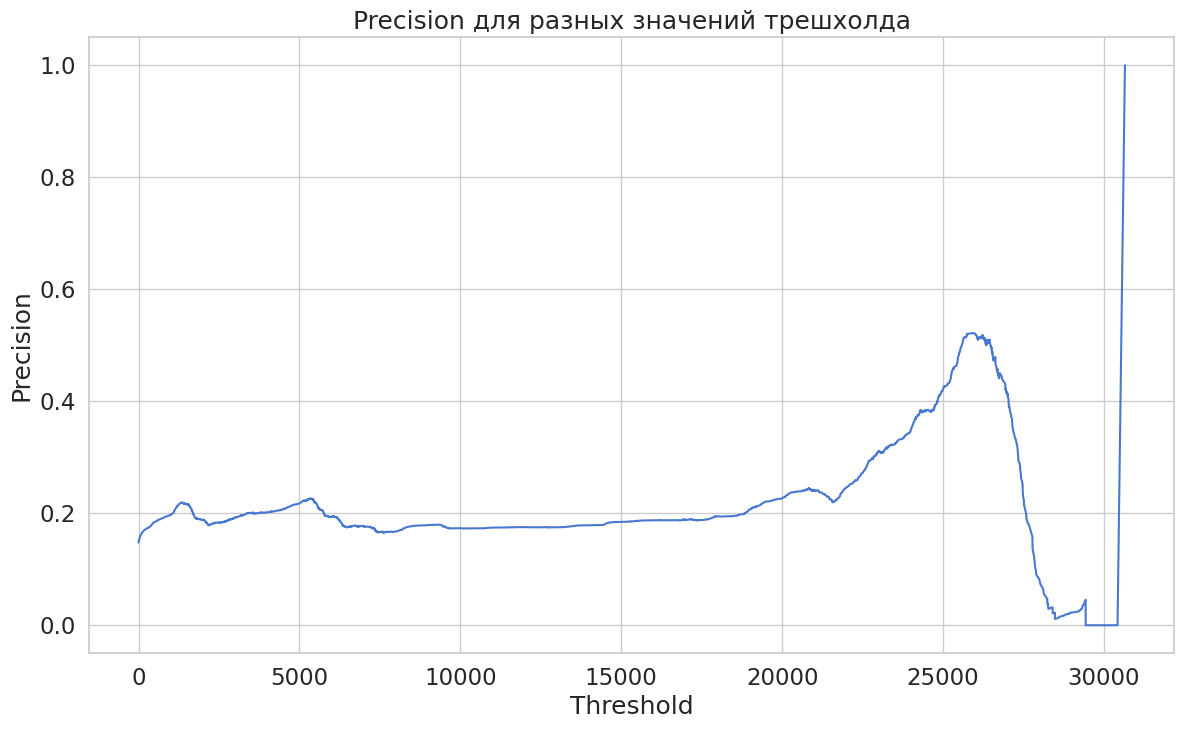

In [174]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

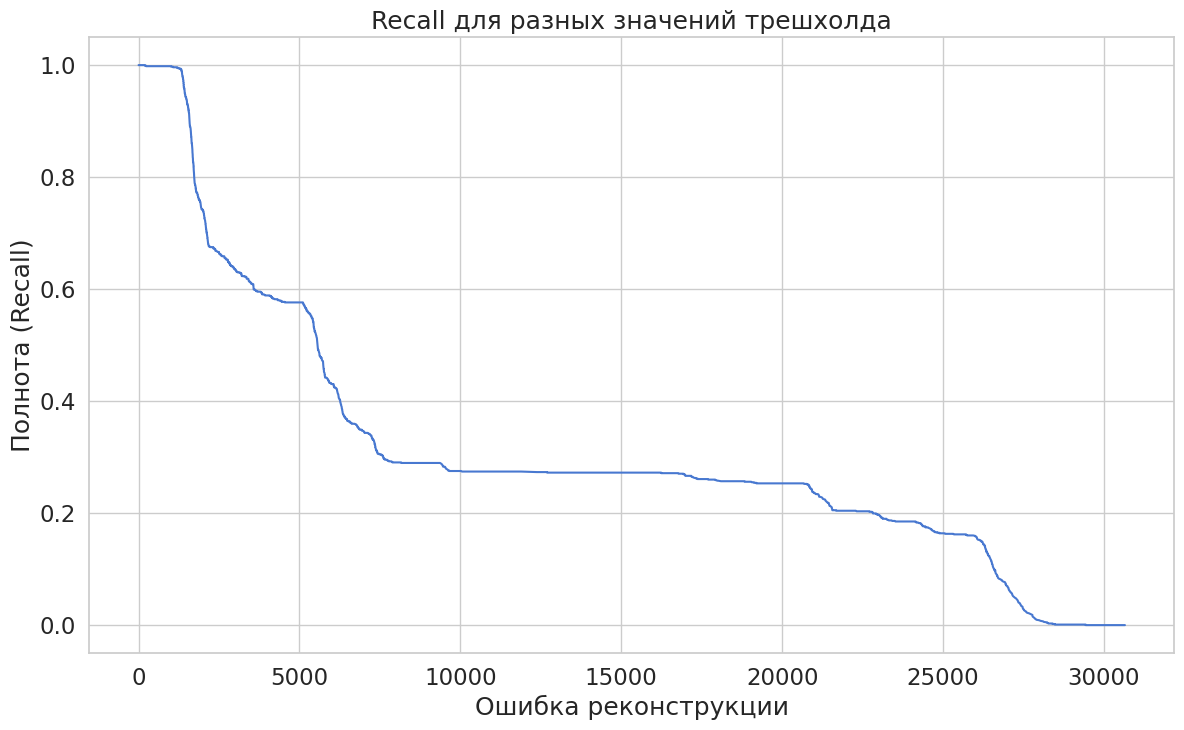

In [175]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

In [176]:
threshold = 2.9

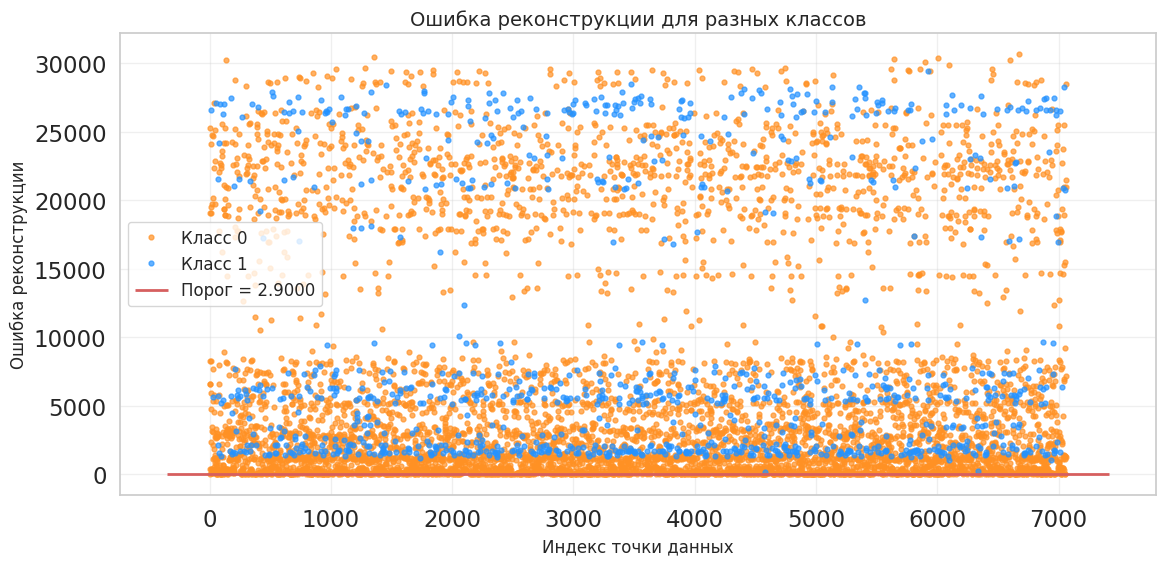

In [178]:
groups = reconstructionErrorDF.groupby('Category ID')
fig, ax = plt.subplots(figsize=(12, 6))

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label="Класс 0" if name == 0 else "Класс 1",
            color='#ff9124' if name == 0 else '#2492ff', alpha=0.7)

# Если threshold определён
if 'threshold' in locals():
    ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r",
              linewidth=2, zorder=100, label=f'Порог = {threshold:.4f}')

ax.legend(fontsize=12)
ax.set_title("Ошибка реконструкции для разных классов", fontsize=14)
ax.set_ylabel("Ошибка реконструкции", size=12)
ax.set_xlabel("Индекс точки данных", size=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

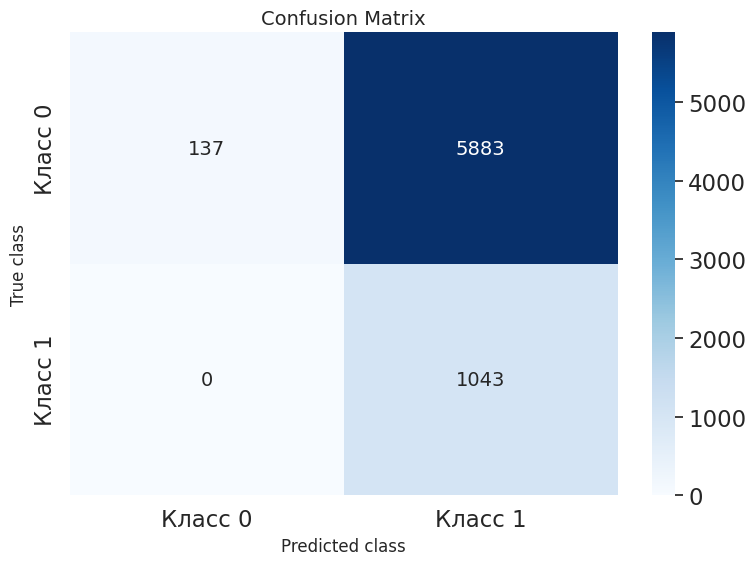


Classification Report:
              precision    recall  f1-score   support

     Класс 0       1.00      0.02      0.04      6020
     Класс 1       0.15      1.00      0.26      1043

    accuracy                           0.17      7063
   macro avg       0.58      0.51      0.15      7063
weighted avg       0.87      0.17      0.08      7063



In [179]:
from sklearn.metrics import confusion_matrix

y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF['pred_loss'].values]
conf_matrix = confusion_matrix(reconstructionErrorDF['Category ID'], y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, xticklabels=['Класс 0', 'Класс 1'],
            yticklabels=['Класс 0', 'Класс 1'],
            annot=True, fmt='d', cmap='Blues',
            annot_kws={'size': 14})
plt.title("Confusion Matrix", fontsize=14)
plt.ylabel('True class', size=12)
plt.xlabel('Predicted class', size=12)
plt.tight_layout()
plt.show()

# Дополнительно: метрики качества
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(reconstructionErrorDF['Category ID'], y_pred,
                            target_names=['Класс 0', 'Класс 1']))

че-то под конец сдулся, совсем плохо определил классы, логистическая регрессия лучше была